# Setup dan Install Library

In [1]:
import os
import re
import pickle
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Tambahkan root project ke sys.path agar bisa import dari src/
import sys
sys.path.insert(0, os.path.abspath('..'))
from src.retrieval.preprocessing import (
    create_stemmer,
    create_stopword_remover,
    clean_text_semantic,
    clean_text_lexical,
    build_combined_text,
)

print("✅ Semua library berhasil diimport")

✅ Semua library berhasil diimport


# Load Data

In [2]:
DATA_PATH = '../data/tourism_with_id.csv'
df = pd.read_csv(DATA_PATH)

print(f"Shape dataset  : {df.shape}")
print(f"Kolom          : {df.columns.tolist()}")
print(f"\nContoh data:")
df.head(3)

Shape dataset  : (437, 13)
Kolom          : ['Place_Id', 'Place_Name', 'Description', 'Category', 'City', 'Price', 'Rating', 'Time_Minutes', 'Coordinate', 'Lat', 'Long', 'Unnamed: 11', 'Unnamed: 12']

Contoh data:


,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Unnamed: 11,Unnamed: 12
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153,NaN,1
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125,NaN,2
2,3,Dunia Fantasi,Dunia Fantasi atau disebut juga Dufan adalah t...,Taman Hiburan,Jakarta,270000,4.6,360.0,"{'lat': -6.125312399999999, 'lng': 106.8335377}",-6.125312,106.833538,NaN,3


# Exploratory Data Analysis

=== Info Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Place_Id      437 non-null    int64  
 1   Place_Name    437 non-null    str    
 2   Description   437 non-null    str    
 3   Category      437 non-null    str    
 4   City          437 non-null    str    
 5   Price         437 non-null    int64  
 6   Rating        437 non-null    float64
 7   Time_Minutes  205 non-null    float64
 8   Coordinate    437 non-null    str    
 9   Lat           437 non-null    float64
 10  Long          437 non-null    float64
 11  Unnamed: 11   0 non-null      float64
 12  Unnamed: 12   437 non-null    int64  
dtypes: float64(5), int64(3), str(5)
memory usage: 379.6 KB
None

=== Missing Values ===
Place_Id          0
Place_Name        0
Description       0
Category          0
City              0
Price             0
Rating            0
Time_Minute

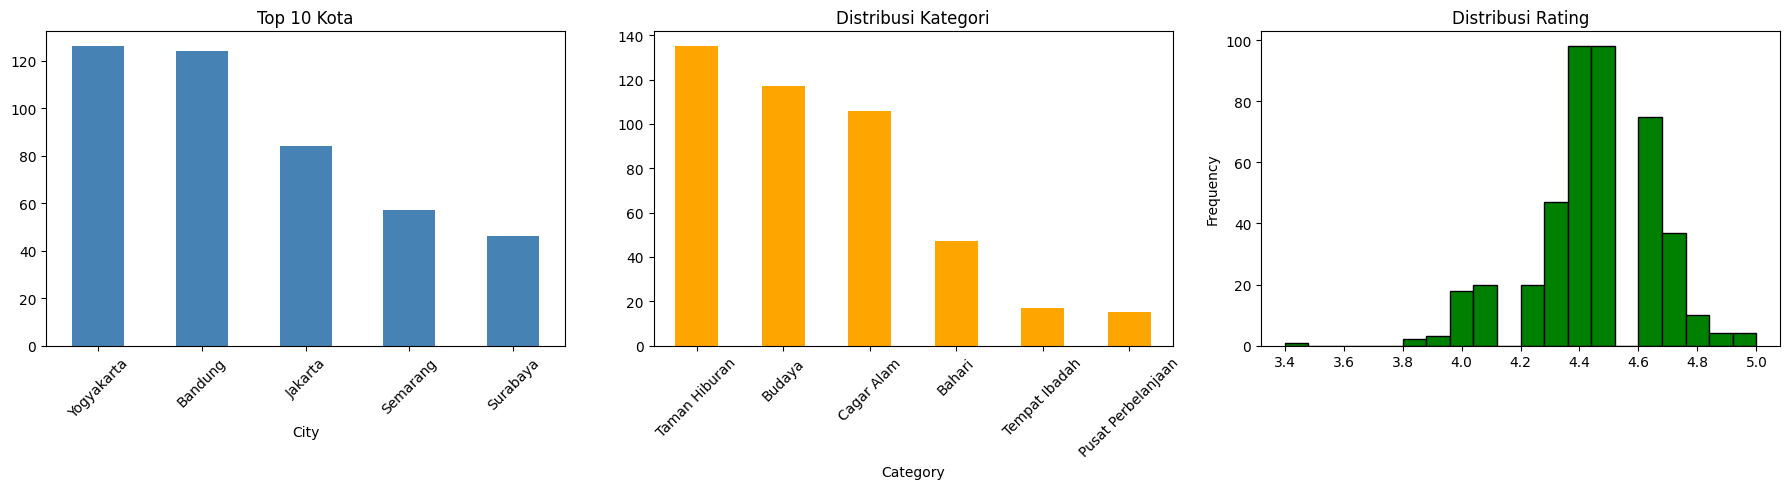

✅ Plot disimpan ke data/eda_plot.png


In [3]:
print("=== Info Dataset ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Distribusi Kategori ===")
print(df['Category'].value_counts())

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['City'].value_counts().head(10).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Kota')
axes[0].tick_params(axis='x', rotation=45)

df['Category'].value_counts().plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Distribusi Kategori')
axes[1].tick_params(axis='x', rotation=45)

df['Rating'].plot(kind='hist', ax=axes[2], bins=20, color='green', edgecolor='black')
axes[2].set_title('Distribusi Rating')

plt.tight_layout()
plt.savefig('../data/eda_plot.png', dpi=120)
plt.show()
print("✅ Plot disimpan ke data/eda_plot.png")

# Inisialisasi Preprocessor

In [5]:
print("Menginisialisasi stemmer PySastrawi... (±5 detik)")
stemmer = create_stemmer()
stopword_remover = create_stopword_remover()
print("✅ Stemmer & stopword remover siap")

# Test
test_text = "Tempat wisata yang sangat indah dan menakjubkan di Bali"
print(f"\nTeks asli     : {test_text}")
print(f"Clean semantic: {clean_text_semantic(test_text)}")
print(f"Clean lexical : {clean_text_lexical(test_text, stemmer, stopword_remover)}")

Menginisialisasi stemmer PySastrawi... (±5 detik)
✅ Stemmer & stopword remover siap

Teks asli     : Tempat wisata yang sangat indah dan menakjubkan di Bali
Clean semantic: tempat wisata yang sangat indah dan menakjubkan di bali
Clean lexical : wisata indah takjub bal


# DUAL-CORPUS PREPROCESSING

In [6]:
# Corpus A: Untuk TF-IDF & BM25 (dengan stemming)
# Corpus B: Untuk Sentence Transformer (tanpa stemming)


# Buat combined_text (gabungkan Place_Name + Description + Category + City)
tqdm.pandas(desc="Membuat combined text")
df['combined_text_raw'] = df.progress_apply(build_combined_text, axis=1)

# --- Corpus A: Lexical (dengan stemming) ---
print("\n🔄 Memproses Corpus A (Lexical, dengan stemming)...")
print("⚠️  Proses ini bisa memakan waktu 5-15 menit tergantung ukuran data...")

corpus_lexical = []
for text in tqdm(df['combined_text_raw'], desc="Stemming"):
    corpus_lexical.append(clean_text_lexical(text, stemmer, stopword_remover))

df['corpus_lexical'] = corpus_lexical
print("✅ Corpus A selesai")

# --- Corpus B: Semantic (tanpa stemming) ---
print("\n🔄 Memproses Corpus B (Semantic, tanpa stemming)...")
df['corpus_semantic'] = df['combined_text_raw'].progress_apply(clean_text_semantic)
print("✅ Corpus B selesai")

# Preview
print("\n=== Preview Dual Corpus ===")
idx = 0
print(f"Combined raw  : {df['combined_text_raw'].iloc[idx][:100]}...")
print(f"Lexical corpus: {df['corpus_lexical'].iloc[idx][:100]}...")
print(f"Semantic corpus:{df['corpus_semantic'].iloc[idx][:100]}...")

Membuat combined text: 100%|██████████| 437/437 [00:00<00:00, 54101.68it/s]



🔄 Memproses Corpus A (Lexical, dengan stemming)...
⚠️  Proses ini bisa memakan waktu 5-15 menit tergantung ukuran data...


Stemming: 100%|██████████| 437/437 [00:00<00:00, 739.06it/s]


✅ Corpus A selesai

🔄 Memproses Corpus B (Semantic, tanpa stemming)...


Membuat combined text: 100%|██████████| 437/437 [00:00<00:00, 19824.68it/s]

✅ Corpus B selesai

=== Preview Dual Corpus ===
Combined raw  : Monumen Nasional Monumen Nasional atau yang populer disingkat dengan Monas atau Tugu Monas adalah mo...
Lexical corpus: monumen nasional monumen nasional populer singkat monas tugu monas monumen ingat 132 meter 433 kaki ...
Semantic corpus:monumen nasional monumen nasional atau yang populer disingkat dengan monas atau tugu monas adalah mo...


# SIMPAN PROCESSED DATASET

In [7]:
os.makedirs('../index', exist_ok=True)

OUTPUT_PATH = '../index/dataset_processed.pkl'
with open(OUTPUT_PATH, 'wb') as f:
    pickle.dump(df, f)

print(f"✅ Dataset tersimpan di: {OUTPUT_PATH}")
print(f"   Shape: {df.shape}")
print(f"   Kolom baru: corpus_lexical, corpus_semantic")

# Verifikasi
df_check = pd.read_pickle(OUTPUT_PATH)
print(f"\nVerifikasi load: {df_check.shape} ✅")

✅ Dataset tersimpan di: ../index/dataset_processed.pkl
   Shape: (437, 16)
   Kolom baru: corpus_lexical, corpus_semantic

Verifikasi load: (437, 16) ✅
